# Trajectory Similarity Metrics — Visual Experiments

> **Goal:** See how alignment, aggregation, ordering, latent geometry, and smoothing change what it means for two trajectories to be similar.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Speed variation** | Why can pointwise distance fail when two trajectories traverse the same path at different speeds? |
| 2 | **Warping constraints** | How does a Sakoe–Chiba band prevent implausible alignments? |
| 3 | **Sum versus bottleneck** | Why do DTW and discrete Fréchet rank persistent error and a single outlier differently? |
| 4 | **Order matters** | Why can Hausdorff distance confuse forward and reverse traversal? |
| 5 | **Latent geometry** | How can Euclidean and Mahalanobis local costs reverse nearest-neighbor ranking? |
| 6 | **Soft-DTW** | What does smoothing the minimum do, and why is raw soft-DTW not automatically a divergence? |

---
**Linked theory:** [Trajectory Similarity Metrics](../research/08-trajectory-similarity-metrics.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10.5,
    'axes.titlesize': 11.5,
    'axes.labelsize': 10.5,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
})


def pairwise_cost(x, y, metric=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.ndim == 1:
        x = x[:, None]
    if y.ndim == 1:
        y = y[:, None]
    if metric is None:
        diff = x[:, None, :] - y[None, :, :]
        return np.linalg.norm(diff, axis=-1)
    return np.array([[metric(a, b) for b in y] for a in x])


def dtw(x, y, metric=None, window=None, warp_penalty=0.0, normalize=False):
    cost = pairwise_cost(x, y, metric)
    n, m = cost.shape
    acc = np.full((n + 1, m + 1), np.inf)
    parent = np.full((n, m, 2), -1, dtype=int)
    acc[0, 0] = 0.0
    for i in range(1, n + 1):
        center = (i - 1) * (m - 1) / max(n - 1, 1)
        for j in range(1, m + 1):
            if window is not None and abs((j - 1) - center) > window:
                continue
            choices = np.array([
                acc[i - 1, j - 1],
                acc[i - 1, j] + warp_penalty,
                acc[i, j - 1] + warp_penalty,
            ])
            move = int(np.argmin(choices))
            acc[i, j] = cost[i - 1, j - 1] + choices[move]
            parent[i - 1, j - 1] = [(i - 2, j - 2), (i - 2, j - 1), (i - 1, j - 2)][move]
    if not np.isfinite(acc[n, m]):
        return np.inf, cost, acc[1:, 1:], []
    path = []
    i, j = n - 1, m - 1
    while i >= 0 and j >= 0:
        path.append((i, j))
        if i == 0 and j == 0:
            break
        i, j = parent[i, j]
    path.reverse()
    value = acc[n, m] / len(path) if normalize else acc[n, m]
    return value, cost, acc[1:, 1:], path


def discrete_frechet(x, y, metric=None):
    cost = pairwise_cost(x, y, metric)
    n, m = cost.shape
    table = np.full((n, m), np.inf)
    parent = np.full((n, m, 2), -1, dtype=int)
    for i in range(n):
        for j in range(m):
            if i == 0 and j == 0:
                table[i, j] = cost[i, j]
                continue
            predecessors = []
            if i > 0 and j > 0:
                predecessors.append((table[i - 1, j - 1], i - 1, j - 1))
            if i > 0:
                predecessors.append((table[i - 1, j], i - 1, j))
            if j > 0:
                predecessors.append((table[i, j - 1], i, j - 1))
            best = min(predecessors, key=lambda item: item[0])
            table[i, j] = max(cost[i, j], best[0])
            parent[i, j] = [best[1], best[2]]
    path = []
    i, j = n - 1, m - 1
    while i >= 0 and j >= 0:
        path.append((i, j))
        if i == 0 and j == 0:
            break
        i, j = parent[i, j]
    path.reverse()
    return table[-1, -1], cost, table, path


def hausdorff(x, y, metric=None):
    cost = pairwise_cost(x, y, metric)
    return max(cost.min(axis=1).max(), cost.min(axis=0).max())


def softmin(values, gamma):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return np.inf
    anchor = finite.min()
    return anchor - gamma * np.log(np.exp(-(finite - anchor) / gamma).sum())


def soft_dtw(x, y, gamma):
    cost = pairwise_cost(x, y) ** 2
    n, m = cost.shape
    acc = np.full((n + 1, m + 1), np.inf)
    acc[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            acc[i, j] = cost[i - 1, j - 1] + softmin(
                [acc[i - 1, j], acc[i, j - 1], acc[i - 1, j - 1]], gamma
            )
    return acc[n, m]


---
## Experiment 1: The same path at different speeds

**Question:** Why does index-wise comparison report a large error even when two trajectories trace nearly the same geometric path?

A nonlinear time warp changes which phase appears at each index without changing the underlying curve. DTW is allowed to recover a monotone correspondence between phases.

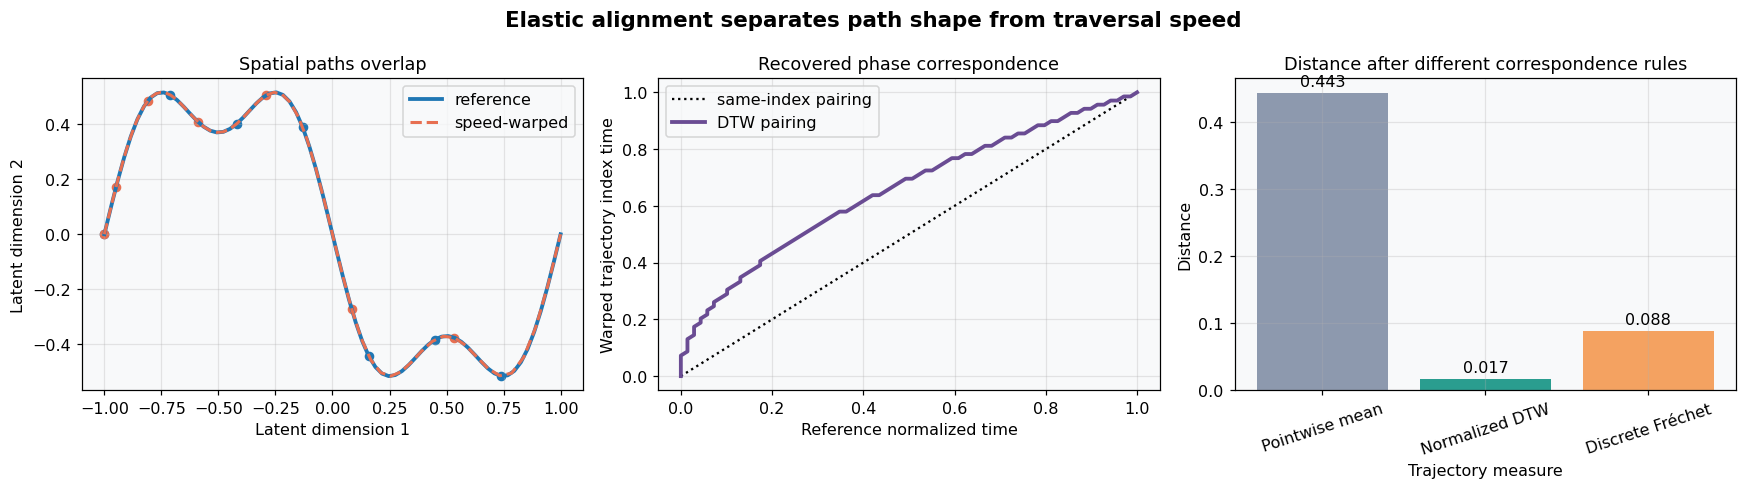

In [2]:
np.random.seed(1)
n = 70
phase = np.linspace(0.0, 1.0, n)
warped_phase = phase ** 1.9

def curve(u):
    return np.column_stack([
        2.0 * u - 1.0,
        0.55 * np.sin(2.0 * np.pi * u) + 0.18 * np.sin(6.0 * np.pi * u),
    ])

reference = curve(phase)
speed_warped = curve(warped_phase)
pointwise = np.linalg.norm(reference - speed_warped, axis=1).mean()
dtw_value, _, _, dtw_path = dtw(reference, speed_warped, normalize=True)
frechet_value, _, _, _ = discrete_frechet(reference, speed_warped)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Elastic alignment separates path shape from traversal speed', fontsize=14, fontweight='bold')

axes[0].plot(reference[:, 0], reference[:, 1], color='#1f77b4', linewidth=2.5, label='reference')
axes[0].plot(speed_warped[:, 0], speed_warped[:, 1], color='#e76f51', linewidth=2.0, linestyle='--', label='speed-warped')
axes[0].scatter(reference[::10, 0], reference[::10, 1], color='#1f77b4', s=28)
axes[0].scatter(speed_warped[::10, 0], speed_warped[::10, 1], color='#e76f51', s=28)
axes[0].set_title('Spatial paths overlap')
axes[0].set_xlabel('Latent dimension 1')
axes[0].set_ylabel('Latent dimension 2')
axes[0].legend()

axes[1].plot(phase, phase, color='black', linestyle=':', label='same-index pairing')
path_array = np.array(dtw_path)
axes[1].plot(phase[path_array[:, 0]], phase[path_array[:, 1]], color='#6a4c93', linewidth=2.5, label='DTW pairing')
axes[1].set_title('Recovered phase correspondence')
axes[1].set_xlabel('Reference normalized time')
axes[1].set_ylabel('Warped trajectory index time')
axes[1].legend()

names = ['Pointwise mean', 'Normalized DTW', 'Discrete Fréchet']
values = [pointwise, dtw_value, frechet_value]
axes[2].bar(names, values, color=['#8d99ae', '#2a9d8f', '#f4a261'])
axes[2].set_title('Distance after different correspondence rules')
axes[2].set_xlabel('Trajectory measure')
axes[2].set_ylabel('Distance')
axes[2].tick_params(axis='x', rotation=18)
for index, value in enumerate(values):
    axes[2].text(index, value + 0.01, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The two spatial curves almost coincide, but markers at the same indices occupy different phases. The DTW path bends away from the diagonal to pair corresponding curve phases.
2. **Why it looks this way:** Pointwise distance fixes correspondence to `(i, i)`. DTW and discrete Fréchet optimize a monotone correspondence, so nonlinear speed variation is treated as a nuisance rather than a state error.
3. **Key takeaway:** Elastic distance is appropriate only when traversal speed should be ignored. If timing is behavior, the low DTW score hides a real difference.

---
## Experiment 2: A warping window is a semantic constraint

**Question:** How does limiting distance from the diagonal change an alignment that would otherwise stretch one event across many samples?

Unconstrained DTW can use long horizontal or vertical runs. A Sakoe–Chiba-style band trades invariance for a bound on temporal distortion.

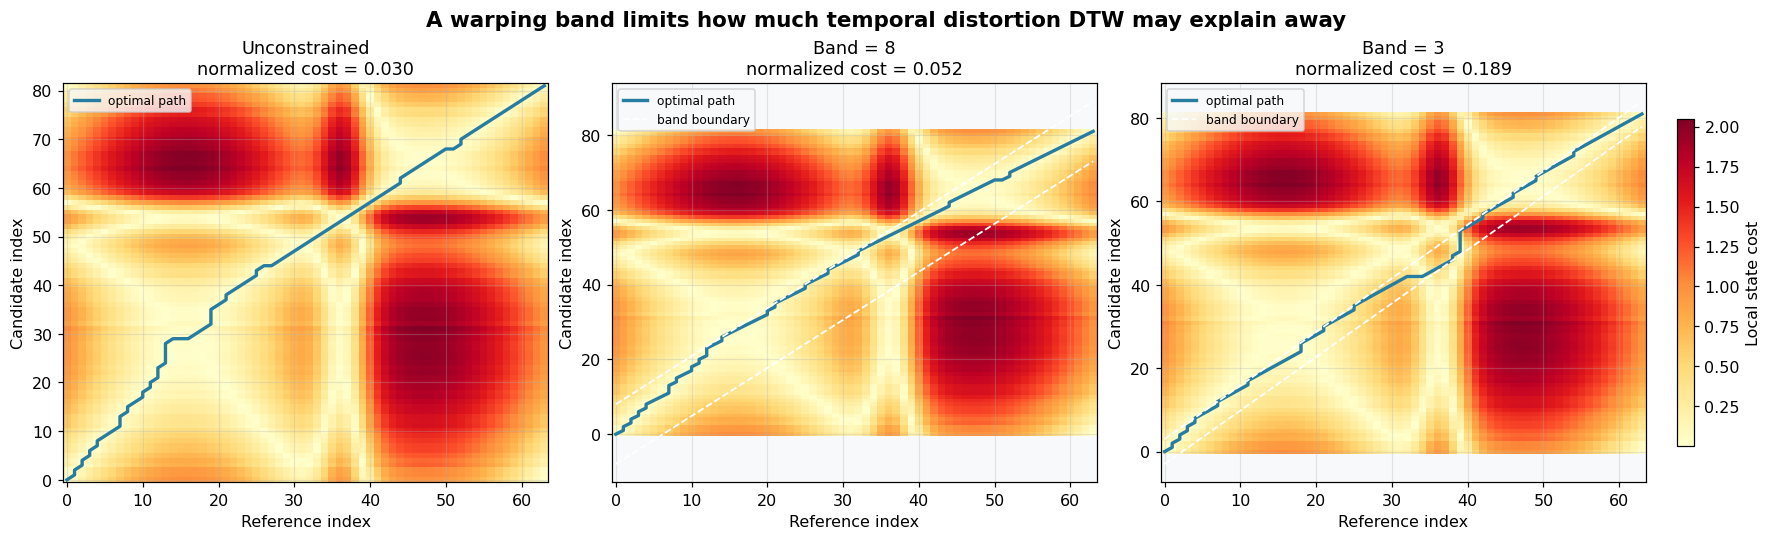

In [3]:
np.random.seed(2)
time_a = np.linspace(0.0, 1.0, 64)
time_b = np.linspace(0.0, 1.0, 82)
signal_a = np.sin(2 * np.pi * time_a) + 1.4 * np.exp(-((time_a - 0.58) / 0.055) ** 2)
warped_b = np.where(time_b < 0.48, 0.72 * time_b, 0.3456 + 1.258 * (time_b - 0.48))
warped_b = np.clip(warped_b, 0.0, 1.0)
signal_b = np.sin(2 * np.pi * warped_b) + 1.4 * np.exp(-((warped_b - 0.58) / 0.055) ** 2)
signal_b += 0.025 * np.random.randn(len(signal_b))

settings = [('Unconstrained', None), ('Band = 8', 8), ('Band = 3', 3)]
results = [dtw(signal_a, signal_b, window=window, normalize=True) for _, window in settings]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), layout='constrained')
fig.suptitle('A warping band limits how much temporal distortion DTW may explain away', fontsize=14, fontweight='bold')

for ax, (label, window), result in zip(axes, settings, results):
    value, cost, _, path = result
    image = ax.imshow(cost.T, origin='lower', aspect='auto', cmap='YlOrRd')
    if path:
        path_array = np.array(path)
        ax.plot(path_array[:, 0], path_array[:, 1], color='#277da1', linewidth=2.2, label='optimal path')
    if window is not None:
        centers = np.arange(len(signal_a)) * (len(signal_b) - 1) / (len(signal_a) - 1)
        ax.plot(np.arange(len(signal_a)), centers - window, color='white', linestyle='--', linewidth=1.2, label='band boundary')
        ax.plot(np.arange(len(signal_a)), centers + window, color='white', linestyle='--', linewidth=1.2)
    ax.set_title(f'{label}\nnormalized cost = {value:.3f}')
    ax.set_xlabel('Reference index')
    ax.set_ylabel('Candidate index')
    ax.legend(loc='upper left', fontsize=8)

fig.colorbar(image, ax=axes, shrink=0.82, pad=0.02, label='Local state cost')
plt.show()

### What you see

1. **What the plot shows:** The unconstrained path makes the largest excursion from the diagonal around the delayed pulse. Narrow bands force the path toward similar timestamps and raise the residual cost.
2. **Why it looks this way:** A wide admissible region lets DTW interpret timing differences as harmless warping. A narrow band declares that correspondences beyond a temporal tolerance are invalid.
3. **Key takeaway:** The window is part of the metric's meaning, not merely an optimization trick. Report it with every DTW result.

---
## Experiment 3: Accumulated error versus bottleneck error

**Question:** Why can normalized DTW prefer one large outlier while discrete Fréchet prefers a small persistent offset?

DTW aggregates local costs along the path. Discrete Fréchet keeps the largest local cost encountered by the best monotone coupling.

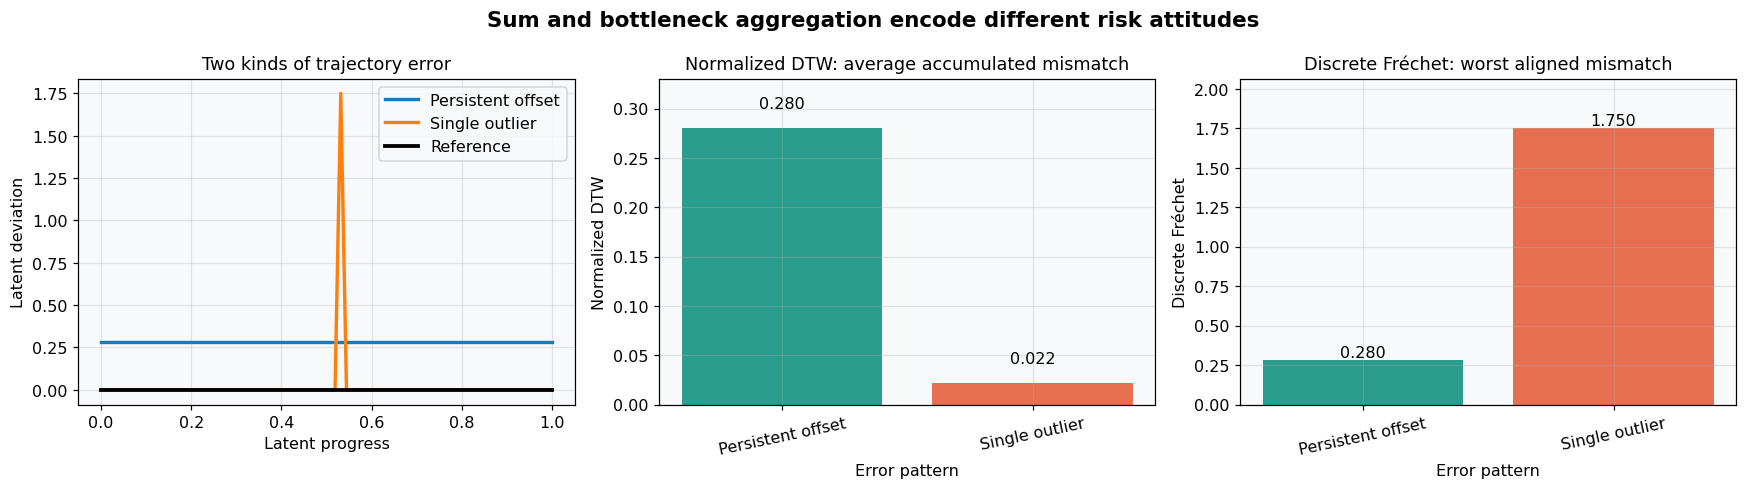

In [4]:
np.random.seed(3)
steps = 80
x_axis = np.linspace(0.0, 1.0, steps)
reference = np.column_stack([x_axis, np.zeros(steps)])
persistent = np.column_stack([x_axis, np.full(steps, 0.28)])
single_outlier = reference.copy()
single_outlier[42, 1] = 1.75

candidates = {'Persistent offset': persistent, 'Single outlier': single_outlier}
dtw_scores = []
frechet_scores = []
for candidate in candidates.values():
    dtw_scores.append(dtw(reference, candidate, normalize=True)[0])
    frechet_scores.append(discrete_frechet(reference, candidate)[0])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Sum and bottleneck aggregation encode different risk attitudes', fontsize=14, fontweight='bold')

for name, candidate in candidates.items():
    axes[0].plot(candidate[:, 0], candidate[:, 1], linewidth=2.2, label=name)
axes[0].plot(reference[:, 0], reference[:, 1], color='black', linewidth=2.5, label='Reference')
axes[0].set_title('Two kinds of trajectory error')
axes[0].set_xlabel('Latent progress')
axes[0].set_ylabel('Latent deviation')
axes[0].legend()

labels = list(candidates.keys())
colors = ['#2a9d8f', '#e76f51']
axes[1].bar(labels, dtw_scores, color=colors)
axes[1].set_title('Normalized DTW: average accumulated mismatch')
axes[1].set_xlabel('Error pattern')
axes[1].set_ylabel('Normalized DTW')
axes[1].tick_params(axis='x', rotation=12)
axes[1].set_ylim(0.0, max(dtw_scores) * 1.18)

axes[2].bar(labels, frechet_scores, color=colors)
axes[2].set_title('Discrete Fréchet: worst aligned mismatch')
axes[2].set_xlabel('Error pattern')
axes[2].set_ylabel('Discrete Fréchet')
axes[2].tick_params(axis='x', rotation=12)
axes[2].set_ylim(0.0, max(frechet_scores) * 1.18)

for ax, values in zip(axes[1:], [dtw_scores, frechet_scores]):
    for index, value in enumerate(values):
        ax.text(index, value + 0.02, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Normalized DTW assigns the persistent offset a larger score because every matched pair contributes. Discrete Fréchet is dominated by the single spike because its objective is the maximum separation.
2. **Why it looks this way:** `min-sum` asks for the cheapest total alignment, while `min-max` asks for the smallest possible worst case.
3. **Key takeaway:** DTW is closer to cumulative distortion; Fréchet is closer to a bottleneck or clearance constraint. The right aggregation depends on the failure being audited.

---
## Experiment 4: A visited set does not contain traversal order

**Question:** Can a set-based distance distinguish clockwise from counterclockwise movement along exactly the same states?

Hausdorff distance matches every point to any nearby point. DTW and Fréchet require a monotone sequence coupling.

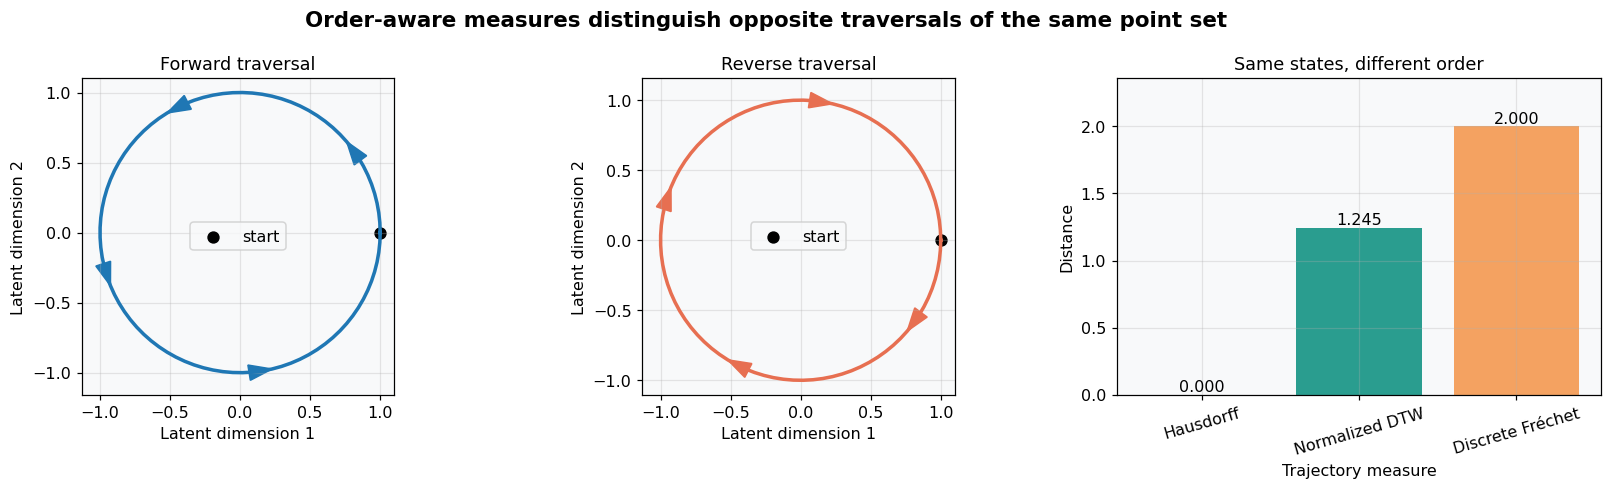

In [5]:
np.random.seed(4)
angle = np.linspace(0.0, 2.0 * np.pi, 90)
forward = np.column_stack([np.cos(angle), np.sin(angle)])
reverse = forward[::-1].copy()

hausdorff_value = hausdorff(forward, reverse)
dtw_value = dtw(forward, reverse, normalize=True)[0]
frechet_value = discrete_frechet(forward, reverse)[0]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))
fig.suptitle('Order-aware measures distinguish opposite traversals of the same point set', fontsize=14, fontweight='bold')

for ax, trajectory, title, color in [
    (axes[0], forward, 'Forward traversal', '#1f77b4'),
    (axes[1], reverse, 'Reverse traversal', '#e76f51'),
]:
    ax.plot(trajectory[:, 0], trajectory[:, 1], color=color, linewidth=2.3)
    for index in [8, 28, 48, 68]:
        delta = trajectory[index + 2] - trajectory[index]
        ax.arrow(trajectory[index, 0], trajectory[index, 1], delta[0], delta[1],
                 color=color, width=0.012, head_width=0.11, length_includes_head=True)
    ax.scatter(trajectory[0, 0], trajectory[0, 1], color='black', s=50, marker='o', label='start')
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('Latent dimension 1')
    ax.set_ylabel('Latent dimension 2')
    ax.legend()

measure_names = ['Hausdorff', 'Normalized DTW', 'Discrete Fréchet']
measure_values = [hausdorff_value, dtw_value, frechet_value]
axes[2].bar(measure_names, measure_values, color=['#8d99ae', '#2a9d8f', '#f4a261'])
axes[2].set_title('Same states, different order')
axes[2].set_xlabel('Trajectory measure')
axes[2].set_ylabel('Distance')
axes[2].tick_params(axis='x', rotation=16)
axes[2].set_ylim(0.0, max(measure_values) * 1.18)
for index, value in enumerate(measure_values):
    axes[2].text(index, value + 0.025, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Forward and reverse trajectories contain the same sampled points, so Hausdorff distance is zero up to numerical precision. DTW and discrete Fréchet remain large.
2. **Why it looks this way:** Hausdorff discards index order and only asks whether each visited state has a nearby state in the other set. Monotone coupling cannot reverse one sequence to match the other.
3. **Key takeaway:** Use set distances for coverage or occupancy, not for causal traversal, action order, or event sequence.

---
## Experiment 5: The local latent metric can reverse retrieval ranking

**Question:** Which candidate is closer when one latent direction naturally varies much more than another?

Alignment only combines local costs. If the local geometry is mis-scaled, a perfectly implemented DTW algorithm optimizes the wrong notion of closeness.

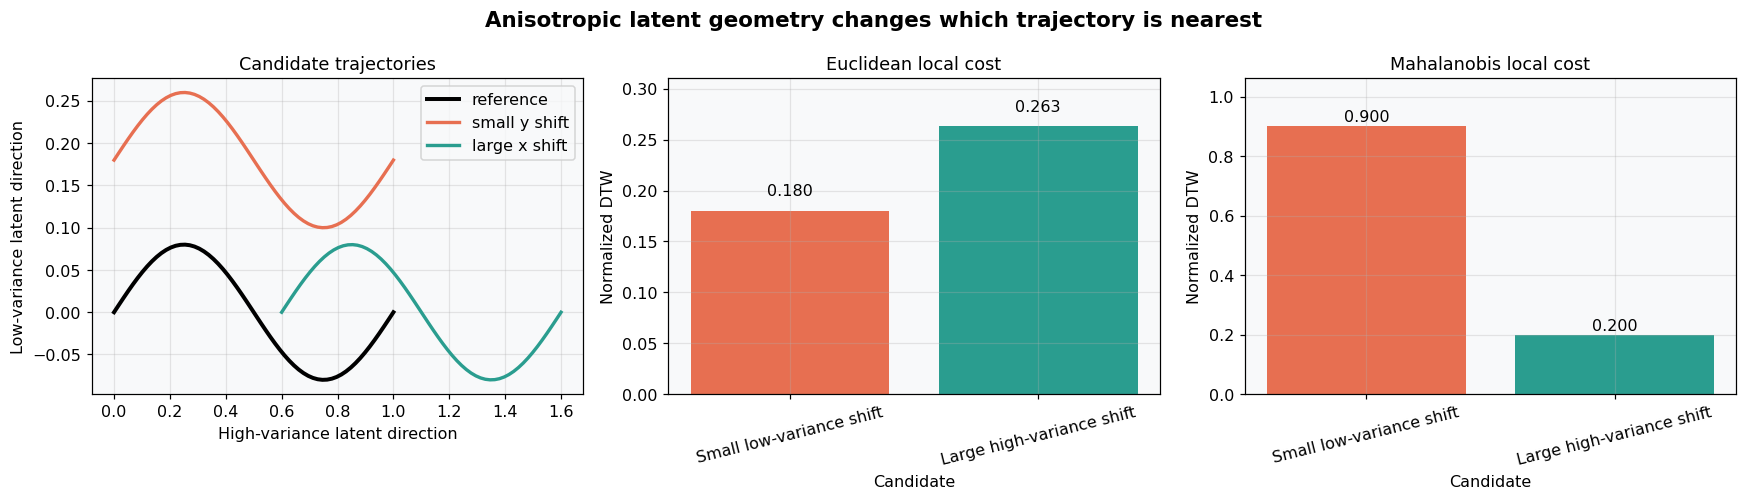

In [6]:
np.random.seed(5)
progress = np.linspace(0.0, 1.0, 60)
reference = np.column_stack([progress, 0.08 * np.sin(2 * np.pi * progress)])
candidate_y = reference + np.array([0.0, 0.18])
candidate_x = reference + np.array([0.60, 0.0])

covariance = np.diag([9.0, 0.04])
precision = np.linalg.inv(covariance)

def mahalanobis(a, b):
    delta = a - b
    return float(np.sqrt(delta @ precision @ delta))

candidate_names = ['Small low-variance shift', 'Large high-variance shift']
candidate_values = [candidate_y, candidate_x]
euclidean_scores = [dtw(reference, candidate, normalize=True)[0] for candidate in candidate_values]
mahalanobis_scores = [dtw(reference, candidate, metric=mahalanobis, normalize=True)[0] for candidate in candidate_values]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
fig.suptitle('Anisotropic latent geometry changes which trajectory is nearest', fontsize=14, fontweight='bold')

axes[0].plot(reference[:, 0], reference[:, 1], color='black', linewidth=2.6, label='reference')
axes[0].plot(candidate_y[:, 0], candidate_y[:, 1], color='#e76f51', linewidth=2.2, label='small y shift')
axes[0].plot(candidate_x[:, 0], candidate_x[:, 1], color='#2a9d8f', linewidth=2.2, label='large x shift')
axes[0].set_title('Candidate trajectories')
axes[0].set_xlabel('High-variance latent direction')
axes[0].set_ylabel('Low-variance latent direction')
axes[0].legend()

colors = ['#e76f51', '#2a9d8f']
axes[1].bar(candidate_names, euclidean_scores, color=colors)
axes[1].set_title('Euclidean local cost')
axes[1].set_xlabel('Candidate')
axes[1].set_ylabel('Normalized DTW')
axes[1].tick_params(axis='x', rotation=14)
axes[1].set_ylim(0.0, max(euclidean_scores) * 1.18)

axes[2].bar(candidate_names, mahalanobis_scores, color=colors)
axes[2].set_title('Mahalanobis local cost')
axes[2].set_xlabel('Candidate')
axes[2].set_ylabel('Normalized DTW')
axes[2].tick_params(axis='x', rotation=14)
axes[2].set_ylim(0.0, max(mahalanobis_scores) * 1.18)

for ax, values in zip(axes[1:], [euclidean_scores, mahalanobis_scores]):
    for index, value in enumerate(values):
        ax.text(index, value + 0.015, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Euclidean DTW prefers the visually smaller shift in the low-variance direction. Mahalanobis DTW reverses the ranking and prefers the larger displacement along the high-variance direction.
2. **Why it looks this way:** Mahalanobis distance measures displacement relative to reference covariance. A `0.18` shift is large when the standard deviation is `0.2`, while a `0.60` shift is modest when the standard deviation is `3.0`.
3. **Key takeaway:** Sequence alignment and latent geometry are separate configuration choices. Always report both.

---
## Experiment 6: Soft-DTW smooths path switches but introduces bias

**Question:** How does temperature change the DTW objective, and why can a raw soft-DTW self-comparison be negative?

Hard DTW chooses one minimum-cost alignment. Soft-DTW uses a soft minimum over all alignments, making the objective differentiable but rewarding alignment entropy.

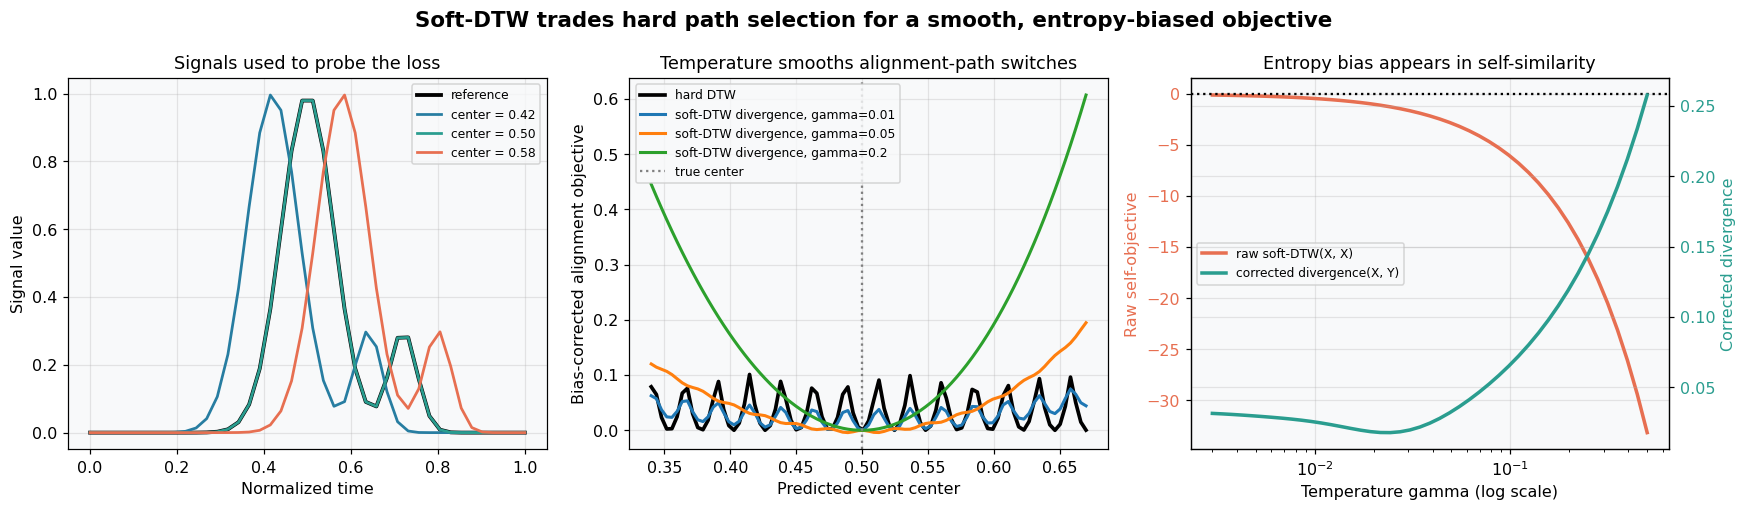

In [7]:
np.random.seed(6)
grid = np.linspace(0.0, 1.0, 42)
reference_signal = np.exp(-((grid - 0.50) / 0.085) ** 2) + 0.30 * np.exp(-((grid - 0.72) / 0.045) ** 2)
center_values = np.linspace(0.34, 0.67, 85)

def shifted_signal(center):
    return np.exp(-((grid - center) / 0.085) ** 2) + 0.30 * np.exp(-((grid - (center + 0.22)) / 0.045) ** 2)

hard_values = []
soft_divergences = {0.01: [], 0.05: [], 0.20: []}
reference_self = {gamma: soft_dtw(reference_signal, reference_signal, gamma) for gamma in soft_divergences}

def squared_local(a, b):
    return float(np.sum((a - b) ** 2))

for center in center_values:
    candidate = shifted_signal(center)
    hard_values.append(dtw(reference_signal, candidate, metric=squared_local)[0])
    for gamma in soft_divergences:
        cross = soft_dtw(reference_signal, candidate, gamma)
        candidate_self = soft_dtw(candidate, candidate, gamma)
        soft_divergences[gamma].append(cross - 0.5 * reference_self[gamma] - 0.5 * candidate_self)

gamma_grid = np.geomspace(0.003, 0.5, 45)
self_values = np.array([soft_dtw(reference_signal, reference_signal, gamma) for gamma in gamma_grid])
other_signal = shifted_signal(0.58)
divergence_values = np.array([
    soft_dtw(reference_signal, other_signal, gamma)
    - 0.5 * soft_dtw(reference_signal, reference_signal, gamma)
    - 0.5 * soft_dtw(other_signal, other_signal, gamma)
    for gamma in gamma_grid
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.7))
fig.suptitle('Soft-DTW trades hard path selection for a smooth, entropy-biased objective', fontsize=14, fontweight='bold')

axes[0].plot(grid, reference_signal, color='black', linewidth=2.5, label='reference')
for center, color in [(0.42, '#277da1'), (0.50, '#2a9d8f'), (0.58, '#e76f51')]:
    axes[0].plot(grid, shifted_signal(center), linewidth=1.8, color=color, label=f'center = {center:.2f}')
axes[0].set_title('Signals used to probe the loss')
axes[0].set_xlabel('Normalized time')
axes[0].set_ylabel('Signal value')
axes[0].legend(fontsize=8)

axes[1].plot(center_values, hard_values, color='black', linewidth=2.4, label='hard DTW')
for gamma, values in soft_divergences.items():
    axes[1].plot(center_values, values, linewidth=2.0, label=f'soft-DTW divergence, gamma={gamma}')
axes[1].axvline(0.50, color='gray', linestyle=':', label='true center')
axes[1].set_title('Temperature smooths alignment-path switches')
axes[1].set_xlabel('Predicted event center')
axes[1].set_ylabel('Bias-corrected alignment objective')
axes[1].legend(fontsize=8)

raw_line = axes[2].semilogx(gamma_grid, self_values, color='#e76f51', linewidth=2.3, label='raw soft-DTW(X, X)')[0]
axes[2].axhline(0.0, color='black', linestyle=':')
axes[2].set_title('Entropy bias appears in self-similarity')
axes[2].set_xlabel('Temperature gamma (log scale)')
axes[2].set_ylabel('Raw self-objective', color='#e76f51')
axes[2].tick_params(axis='y', labelcolor='#e76f51')
divergence_axis = axes[2].twinx()
divergence_line = divergence_axis.semilogx(gamma_grid, divergence_values, color='#2a9d8f', linewidth=2.3, label='corrected divergence(X, Y)')[0]
divergence_axis.set_ylabel('Corrected divergence', color='#2a9d8f')
divergence_axis.tick_params(axis='y', labelcolor='#2a9d8f')
axes[2].legend([raw_line, divergence_line], [raw_line.get_label(), divergence_line.get_label()], fontsize=8, loc='center left')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Increasing `gamma` rounds the hard objective because multiple alignments contribute near every path switch. Raw soft-DTW of a signal with itself becomes negative as temperature grows, while the self-corrected divergence remains interpretable relative to zero.
2. **Why it looks this way:** The soft minimum includes an entropy term. More near-optimal paths lower the raw objective even when no geometric mismatch exists.
3. **Key takeaway:** Soft-DTW is useful as a differentiable alignment loss, but its raw value is not automatically a non-negative distance. Use a corrected divergence when that property matters.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Speed variation | Elastic alignment can recover shared shape while deliberately discarding traversal speed. |
| 2. Warping constraints | A window defines the maximum timing distortion that the measure may explain away. |
| 3. Sum versus bottleneck | DTW measures accumulated mismatch; Fréchet measures the worst aligned mismatch. |
| 4. Order matters | Set distances preserve occupancy but can erase traversal direction and causal order. |
| 5. Latent geometry | A sequence metric is only as meaningful as its local state metric. |
| 6. Soft-DTW | Differentiability comes from averaging over paths and introduces entropy bias. |

### Practical default

For a new latent-trajectory task, start with a standardized or Mahalanobis local cost, normalized DTW with a moderate timestamp-aware window, and discrete Fréchet as a separate worst-case diagnostic. Keep a pointwise timing score so that elastic alignment cannot silently erase behaviorally important delay.